playground is to define 2d and og functions and build a caller based to user input to determine which plot to generate

In [2]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import utils
import nist_codes
import matplotlib.patheffects as pe
import new_utils

In [3]:
H_SHEET = "h test.xlsx"
HE_SHEET = "he test.xlsx"
NIST_SHEET = "oxygen nist 2.xlsx"

global df  
df = pd.read_excel(HE_SHEET)

In [4]:
detection_col = '_raw_int'
int_col = '_adj_int'

In [5]:
def get_generic_type():
    global generic_type
    gen_type = (input('Choose Rendering: Raw or Normalised')).lower()
    if gen_type == 'raw' or gen_type == 'r':
        generic_type = 'raw'
    elif gen_type == 'normalised' or gen_type == 'norm' or gen_type == 'n':
        generic_type = 'normalised'
    
    print (generic_type)
    return generic_type

In [6]:
# ax. ... values don't pass when trad_spec_labels() is called
    # FIX: had to add parameters and pass them along in trad_spec()

def trad_spec_labels(fig, ax, x_min, x_max,):
    new_utils.get_mode()
    new_utils.text_colour()

    global figure_bg_color
    global text_color
    
    if new_utils.mode == 'dark':
        figure_bg_color = 'black'
        text_color = new_utils.colour
    elif new_utils.mode == 'light':
        figure_bg_color = 'white'
        text_color = new_utils.colour
    print("mode:", new_utils.mode, ", fig bg colour:", figure_bg_color)

    fig.patch.set_facecolor(figure_bg_color)
    ax.set_facecolor('black')  
    ax.yaxis.set_visible(False)
    ax.set_xlabel(new_utils.x_title, color=text_color)
    ax.xaxis.set_major_locator(utils.major_locator)
    ax.xaxis.set_minor_locator(utils.minor_locator)
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0,1)

In [7]:
def prep_trad_spec(data_df, force_nist, x_min, x_max, apply_descriptor_adjustments,):

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[new_utils.wl_col] = pd.to_numeric(df_plot_data[new_utils.wl_col], errors='coerce')

    # run NIST detector
    has_any_nist, nist_diag = nist_codes.detect_nist_values(df_plot_data[new_utils.INT_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        print('NIST Destriptors Detected. Preparing NIST Rendering.')
    else:
        df_plot_data = utils.prepare_generic_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        print('No NIST Destriptors Detected. Preparing Generic Rendering.')

    # parse NIST-style cells
    parsed_intensity = df_plot_data[new_utils.INT_col].apply(nist_codes.parse_nist_intensity)
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[new_utils.wl_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[new_utils.wl_col] >= x_min) & (df_plot_data[new_utils.wl_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=new_utils.wl_col).reset_index(drop=True)

    # returns empty flag for empty datasets
    if df_plot_data.empty:
        return None, True 

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range

    return df_plot_data, False, has_any_nist


need to have code run nist detector first, if nist data detected, run trad_spec(). 
can't have other formats work with nist data because only strong lines are included. would have to do a "reverse calibration" to find in between values in order to plot other graphs. 
    exception might be gaussian plots. b/c gaussian is similar to trad, might be able to have it deal with nist data

1. run nist detector
2. if nist data detected, prompt user: "Nist Data Detected. Choose: Gaussian or Traditional Graph Type.", render accordingly
3. if NO nist data detected, run like normal (like current setup)

In [8]:
new_utils.res_col_names(data_df=df, nm_col=None, int_col=None)

# default df_filtered
df_filtered = df[(df[new_utils.wl_col] >= 400) & (df[new_utils.wl_col] <= 750)].copy()
df_filtered = df_filtered.sort_values(by=new_utils.wl_col).reset_index(drop=True)
print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())


# smoothed df_filtered
df_filtered['Smoothed_int'] = df_filtered[new_utils.INT_col].rolling(window=new_utils.smoothing_window, center=True).mean().fillna(df_filtered[new_utils.INT_col])

if new_utils.plot_type == 'Smoothed':
    min_int = df_filtered['Smoothed_int'].min
    max_int = df_filtered['Smoothed_int'].max
else:
    min_int = df_filtered[new_utils.INT_col].min()
    max_int = df_filtered[new_utils.INT_col].max()

int_range = max_int - min_int

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    if new_utils.plot_type == 'Smoothed':
        df_filtered['Normalized_int'] = (df_filtered['Smoothed_int'] - min_int) / int_range
    else:
        df_filtered['Normalized_int'] = (df_filtered[new_utils.INT_col] - min_int) / int_range

print(df_filtered['Normalized_int'])

nm Grey Val
DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  
0      0.014325
1      0.019503
2      0.026315
3      0.032659
4      0.037609
         ...   
305    0.003031
306    0.000565
307    0.000000
308    0.000876
309    0.001914
Name: Normalized_int, Length: 310, dtype: float64


In [9]:
# have to figure out how to call it properly in the other functions. might just have to keep it outside of the function (like above)


def prep_other_spec(df):

    new_utils.res_col_names(data_df=df, nm_col=None, int_col=None)

    # default df_filtered
    df_filtered = df[(df[new_utils.wl_col] >= 400) & (df[new_utils.wl_col] <= 750)].copy()
    df_filtered = df_filtered.sort_values(by=new_utils.wl_col).reset_index(drop=True)
    print("DataFrame loaded successfully. Here are the first 5 rows:")
    print(df.head())

    # smoothed df_filtered
    df_filtered['Smoothed_int'] = df_filtered[new_utils.INT_col].rolling(window=new_utils.smoothing_window, center=True).mean().fillna(df_filtered[new_utils.INT_col])

    if new_utils.plot_type == 'Smoothed':
        min_int = df_filtered['Smoothed_int'].min
        max_int = df_filtered['Smoothed_int'].max
    else:
        min_int = df_filtered[new_utils.INT_col].min()
        max_int = df_filtered[new_utils.INT_col].max()

    int_range = max_int - min_int

    if int_range == 0:
        df_filtered['Normalized_int'] = 1.0
    else:
        if new_utils.plot_type == 'Smoothed':
            df_filtered['Normalized_int'] = (df_filtered['Smoothed_int'] - min_int) / int_range
        else:
            df_filtered['Normalized_int'] = (df_filtered[new_utils.INT_col] - min_int) / int_range
    
    # returns empty flag for empty datasets
    if df_filtered.empty:
        return None, True 

    # Success! Return the completed dataframe and False (do not exit early)
    return df_filtered, False


In [10]:
# updated to work with trad_spec(). eventually want it to work with set_generic_type()

def plot(
    df_plot_data,
    nm_col,
    has_any_nist,
    prominence_percentage=0,     
    fig_size=utils.FIG_SIZE,
    min_brightness=0,
    peak_wavelengths=None,
    show_peak_labels=True,
    x_min=utils.X_MIN,
    x_max=utils.X_MAX,
    min_needle_max_width_nm=utils.MIN_NEEDLE_WIDTH,
    max_needle_max_width_nm=utils.MAX_NEEDLE_WIDTH,
    needle_shape_power=utils.NEEDLE_POWER_SHAPE,
    glow_width_multiplier=utils.GLOW_WIDTH_MULT,
    glow_alpha=0,
    dpi=utils.DPI,
    peak_label_y_position=0,
    label_min_norm_int=utils.LABEL_NORM_INT,
    apply_descriptor_adjustments = False,
    subplots_adjust_top = 0.90,
    max_needle_y = utils.MAX_Y_SCALE,
    fig_height_overflow_scale = utils.fig_height_overflow_scale,
    fig_height_base = utils.FIG_HEIGHT_BASE,
):

    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    trad_spec_labels(fig=fig, ax=ax, x_min=x_min, x_max=x_max)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        min_brightness = utils.DEFAULT_MIN_BRIGHT
        glow_alpha = utils.DEFAULT_GLOW_ALPHA
        prominence_percentage = utils.DEFAULT_PROM_PERC
        peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN

    else:
        df_plot_data = utils.prepare_generic_spectrum(df_plot_data, new_utils.INT_col, apply_descriptor_adjustments)
        get_generic_type()
        if generic_type == 'raw':
            glow_alpha = utils.DEFAULT_GLOW_ALPHA
            peak_label_y_position = utils.DEFAULT_PEAK_LABEL_POSN
        elif generic_type == 'normalised' or generic_type == 'n':
            glow_alpha = utils.NORM_GLOW_ALPHA
            peak_label_y_position = utils.NORM_PEAK_LABEL_POSN

    # --- Peak Detection ---
    if peak_wavelengths is not None:
        nm_vals = df_plot_data[new_utils.wl_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    elif has_any_nist:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        if generic_type=='raw' or generic_type == 'r':
            prominence_percentage = utils.DEFAULT_PROM_PERC
        if generic_type == 'normalised' or generic_type == 'n':
            prominence_percentage = utils.NORM_PROM_PERC
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        peaks, _ = find_peaks(df_plot_data[new_utils.INT_col], prominence=dynamic_prominence)
    
    peak_nms = [float(df_plot_data.iloc[index][new_utils.wl_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]

    init_peak_label_y_posn = peak_label_y_position
    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=init_peak_label_y_posn,
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [init_peak_label_y_posn] * len(peaks)

    if label_ys:
        max_label_y = max(label_ys)
        overflow = max(0, max_label_y - init_peak_label_y_posn)
        print("\noverflow:", overflow)
        print("o.g. peak label y pos'n:", init_peak_label_y_posn)
        if overflow > 0:
            new_height = fig_height_base + overflow * fig_height_overflow_scale
            new_fig_height = new_height
            fig.set_figheight(new_height)
           
            current_needle_height_in = max_needle_y * new_height
            new_needle_height = (max_needle_y * fig_height_base) / new_height 
            max_needle_y_scale = new_needle_height
            new_peak_y_posn = (init_peak_label_y_posn * fig_height_base) / new_height
            peak_label_y_position = new_peak_y_posn
            
            print("needle height goal:", new_needle_height, "\n \t inches:", new_needle_height*new_height)
            print("current needle height (in):", current_needle_height_in)
            print("height:", new_height, "max label y:", max_label_y)
            print("\npeak label y pos'n goal:", new_peak_y_posn, "\nnew fig height:", new_fig_height)      
        else:
            print("Labels fit — no expansion needed")
            max_needle_y_scale = max_needle_y
            print("peak label y pos'n:", peak_label_y_position)
    else:
        max_needle_y_scale = max_needle_y
        print("No labels on this spectrum")

    print(f"DEBUG: max_label_y = {max(label_ys) if label_ys else 'N/A'}")

    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=peak_label_y_position,   # now uses updated value
            min_sep_nm=1.5,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.85,
        )
    except Exception:
        label_ys = [peak_label_y_position] * len(peaks)

    print("\n new peak label pos'n:", peak_label_y_position)

    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[nm_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = utils.wavelength_to_rgb(_nm)
        _final_scale = new_utils.final_scale(min_brightness, _ni)
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = new_utils.left_x(_nm, _bg_widths)
        _x_right = new_utils.right_x(_nm, _bg_widths)
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']
        base_rgb = utils.wavelength_to_rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        if has_any_nist or generic_type == 'raw' or generic_type == 'r':
            _peak_emphasis = utils.DEFAULT_PEAK_EMPHASIS
            min_brightness = utils.DEFAULT_MIN_BRIGHT
        elif generic_type == 'normalised' or generic_type == 'norm' or generic_type == 'n':
            _peak_emphasis = utils.NORM_PEAK_EMPHASIS
            min_brightness = utils.NORM_MIN_BRIGHT
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)

        color_rgb = new_utils.colored_rgb(base_rgb, final_int_scale)

        # Scale the maximum width of the needle based on normalized intensity
        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)

        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost
        
        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render))

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = new_utils.left_x(peak_nm, glow_current_widths_nm)
        glow_x_right = new_utils.right_x(peak_nm, glow_current_widths_nm)
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=color_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = new_utils.dynamic_prominence(scaled_max_width_nm, width_profile_factor)
        x_left = new_utils.left_x(peak_nm, current_widths_nm)
        x_right = new_utils.right_x(peak_nm, current_widths_nm)
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=color_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    if has_any_nist or generic_type == 'raw':
        pad = 15
    else:
        pad = 10
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.title(f'{generic_type.capitalize()} Emission Spectrum Visualization ({new_utils.mode.capitalize()} Mode)', color=new_utils.colour, y=0.98, pad=pad)
    plt.subplots_adjust(top=subplots_adjust_top)

    print("\nDEBUG: fig height = ", fig.get_figheight(), "\n current needle height = ", current_peak_render_height)

    return fig, ax

In [11]:
def trad_spec(
    data_df,
    nm_col = None,
    int_col = None,
    x_min=utils.X_MIN,
    x_max=utils.X_MAX,
    fig_size=utils.FIG_SIZE,
    dpi=utils.DPI,
    force_nist=None,
    apply_descriptor_adjustments = False,
):
   
    new_utils.res_col_names(data_df, nm_col=nm_col, int_col=int_col)

    df_plot_data, should_exit_early, has_any_nist = prep_trad_spec(data_df = data_df, 
                                                              force_nist = force_nist, 
                                                              x_min = x_min, 
                                                              x_max = x_max,
                                                              apply_descriptor_adjustments=apply_descriptor_adjustments,)
    if should_exit_early:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        print("Ending Rendering Early.")
        return fig
    
    # Create the plot (use explicit Figure/Axis to avoid side-effects)
    fig, ax = plot(df_plot_data = df_plot_data, nm_col = new_utils.wl_col, has_any_nist=has_any_nist)
    
    return fig

In [12]:
def line_plot_iteration():
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i][new_utils.wl_col]
        wavelength_end = df_filtered.iloc[i+1][new_utils.wl_col]
        int_factor = df_filtered.iloc[i]['Normalized_int']
        base_rgb = new_utils.rgb(wavelength_start)
        final_intensity_scale = new_utils.final_scale(new_utils.min_bright, int_factor)
        color_rgb = new_utils.colored_rgb(base_rgb, final_intensity_scale)
        plt.plot([wavelength_start, wavelength_end],
                [df_filtered.iloc[i][new_utils.INT_col], df_filtered.iloc[i+1][new_utils.INT_col]],
                color=color_rgb,
                linewidth=2)

In [13]:
def filled_plot():
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i][new_utils.wl_col]
        wavelength_end = df_filtered.iloc[i+1][new_utils.wl_col]
        base_rgb = new_utils.rgb(wavelength_start)
        alpha_factor = df_filtered.iloc[i]['Normalized_int']
        alpha = new_utils.final_scale(new_utils.min_alpha, alpha_factor)

        if new_utils.plot_type == 'Smoothed':
            plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0], # Base of the fill is y=0
                     [df_filtered.iloc[i]['Smoothed_int'], df_filtered.iloc[i+1]['Smoothed_int']], # Top of the fill
                     color=base_rgb,
                     alpha=alpha,
                     linewidth=0) # No line for the fill edges
        else:
            plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0], # Base of the fill is y=0
                        [df_filtered.iloc[i][new_utils.INT_col], df_filtered.iloc[i+1][new_utils.INT_col]], # Top of the fill
                        color=base_rgb,
                        alpha=alpha,
                        linewidth=0) # No line for the fill edges
            
            # Plot the line on top for clarity, using the base color for the line itself
            plt.plot([wavelength_start, wavelength_end],
                    [df_filtered.iloc[i][new_utils.INT_col], df_filtered.iloc[i+1][new_utils.INT_col]],
                    color=base_rgb,
                    linewidth=2) # Thicker line for better visibility on top of fill

In [14]:
def gaussian_iteration():
    # Detect peaks
    dyn_prominence = new_utils.dynamic_prominence(new_utils.prominence, int_range)
    peaks_indices, properties = find_peaks(df_filtered[new_utils.INT_col], prominence=dyn_prominence)

    # Create a new, denser wavelength array for plotting the synthetic spectrum
    x_synthetic = np.linspace(400, 750, 1000) # 1000 points for a smooth synthetic curve
    y_synthetic = np.zeros_like(x_synthetic)

    for i, peak_idx in enumerate(peaks_indices):
        peak_nm = df_filtered.iloc[peak_idx][new_utils.wl_col]
        peak_amplitude = df_filtered.iloc[peak_idx][new_utils.INT_col]
        normalized_amplitude = df_filtered.iloc[peak_idx]['Normalized_int']

        # Scale sigma based on normalized intensity (higher intensity = broader peak)
        sigma = new_utils.base_sigma_nm + (new_utils.max_sigma_multiplier - 1) * new_utils.base_sigma_nm * normalized_amplitude

        # Create a Gaussian curve for this peak
        gaussian_curve = peak_amplitude * np.exp(-((x_synthetic - peak_nm)**2) / (2 * sigma**2))
        y_synthetic += gaussian_curve # Add to the total synthetic spectrum

    # Normalize the synthetic spectrum intensities for coloring (if desired, not strictly necessary for area plot)
    min_y_synthetic = y_synthetic.min()
    max_y_synthetic = y_synthetic.max()
    if (max_y_synthetic - min_y_synthetic) == 0:
        normalized_y_synthetic = np.ones_like(y_synthetic)
    else:
        normalized_y_synthetic = (y_synthetic - min_y_synthetic) / (max_y_synthetic - min_y_synthetic)

        # Iterate through each segment of the synthetic spectrum to apply color and alpha
    for i in range(len(x_synthetic) - 1):
        wavelength_start = x_synthetic[i]
        wavelength_end = x_synthetic[i+1]
        base_rgb = new_utils.rgb(wavelength_start, gamma=new_utils.gamma_factor)
        alpha = new_utils.final_scale(new_utils.min_alpha, normalized_y_synthetic[i])
        plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0],
                        [y_synthetic[i], y_synthetic[i+1]],
                        color=base_rgb,
                        alpha=alpha,
                        linewidth=0)

In [15]:
def scatter_iteration():
    alpha_factor = df_filtered['Normalized_int']
    sizes = new_utils.base_marker_size + (new_utils.max_marker_size_factor * alpha_factor)
    alphas = new_utils.final_scale(new_utils.min_alpha_scatter, alpha_factor)
    rgba_colors = []
    for i in range(len(df_filtered)):
        wavelength = df_filtered.iloc[i][new_utils.wl_col]
        r, g, b = new_utils.rgb(wavelength)
        a = alphas.iloc[i]
        rgba_colors.append((r, g, b, a))
    plt.scatter(
        x=df_filtered[new_utils.wl_col],
        y=df_filtered[new_utils.INT_col],
        c=rgba_colors,
        s=sizes,
        edgecolors='none',
        label='Emission Data'
    )

In [16]:
def bar_iteration():
    bar_colors = []
    for index, row in df_filtered.iterrows():
        wavelength = row[new_utils.wl_col]
        normalized_intensity = row['Normalized_int']

        if new_utils.mode == 'dark':
            BRIGHT = 0.1
        if new_utils.mode == 'light':
            BRIGHT = 0.7

        base_rgb = new_utils.rgb(wavelength)
        final_intensity_scale = new_utils.final_scale(BRIGHT, normalized_intensity)
        color_rgb = new_utils.colored_rgb(base_rgb, final_intensity_scale)
        bar_colors.append(color_rgb)
    plt.bar(
        x=df_filtered[new_utils.wl_col],
        height=df_filtered[new_utils.INT_col],
        width=new_utils.bar_width,
        color=bar_colors,
        edgecolor='none' # No edge color for bars
    )

In [17]:
def get_graph_type():
    GRAPH_TYPE = input("Choose Graph Type: Line, Bar, Scatter, Gaussian, Traditional").lower()
    global graph_type
    
    if GRAPH_TYPE == 'bar' or GRAPH_TYPE == 'b':
        graph_type = 'bar'
    elif GRAPH_TYPE == 'scatter' or GRAPH_TYPE == 's':
        graph_type = 'scatter'
    elif GRAPH_TYPE == 'gaussian' or GRAPH_TYPE == 'g':
        graph_type = 'gaussian'
    elif GRAPH_TYPE == 'line' or GRAPH_TYPE == 'l':
        graph_type = 'line'           
    elif GRAPH_TYPE == 'traditional' or GRAPH_TYPE == 'trad' or GRAPH_TYPE == 't':
        graph_type = 'traditional'
    
    print('Graph Type:', graph_type)
    return graph_type

In [18]:
def plot_other_spec():
    new_utils.axis_labels()
    
    if graph_type == 'bar':
        bar_iteration()
        plt.title("Bar Chart", color = new_utils.colour)
    elif graph_type == 'scatter':
        scatter_iteration()
        plt.title("Scatter Plot", color=new_utils.colour)
    elif graph_type == 'gaussian':
        gaussian_iteration()
        plt.title("Gaussian Plot", color = new_utils.colour)
    elif graph_type == 'line':
        FILL_TYPE = input("Filled Graph? Choose: Yes or No").lower()
        if FILL_TYPE == 'yes' or FILL_TYPE == 'y':
            PLOT_TYPE = input("Smoothed Fill? Choose: Yes or No").lower()
            if PLOT_TYPE == 'yes' or PLOT_TYPE == 'y':
                new_utils.plot_type == 'Smoothed'
                filled_plot()
                plt.title("Smoothed Plot", color = new_utils.colour)
            else:
                new_utils.plot_type is None
                filled_plot()
                plt.title("Filled Plot", color = new_utils.colour)
        else:
            line_plot_iteration()
            plt.title("Line Plot", color = new_utils.colour)

In [19]:
def plot_trad_spec():
    if graph_type == 'traditional':
        trad_spec(df)

In [20]:
def plot_graph():
    get_graph_type()
    if graph_type == 'bar' or graph_type == 'scatter' or graph_type == 'line' or graph_type == 'gausian':
        plot_other_spec()
    elif graph_type == 'traditional':
        plot_trad_spec()
        plt.show()
    else:
        print ("Graph Type Not Recognised")

In [21]:
plot_graph()
plt.show()

NameError: name 'graph_type' is not defined

nm Grey Val
No NIST Destriptors Detected. Preparing Generic Rendering.


mode: dark
text colour: white face/bg colour: black
mode: dark , fig bg colour: black
raw

overflow: 0
o.g. peak label y pos'n: 0.77
Labels fit — no expansion needed
peak label y pos'n: 0.77
DEBUG: max_label_y = 0.77

 new peak label pos'n: 0.77

DEBUG: fig height =  3.0 
 current needle height =  0.75


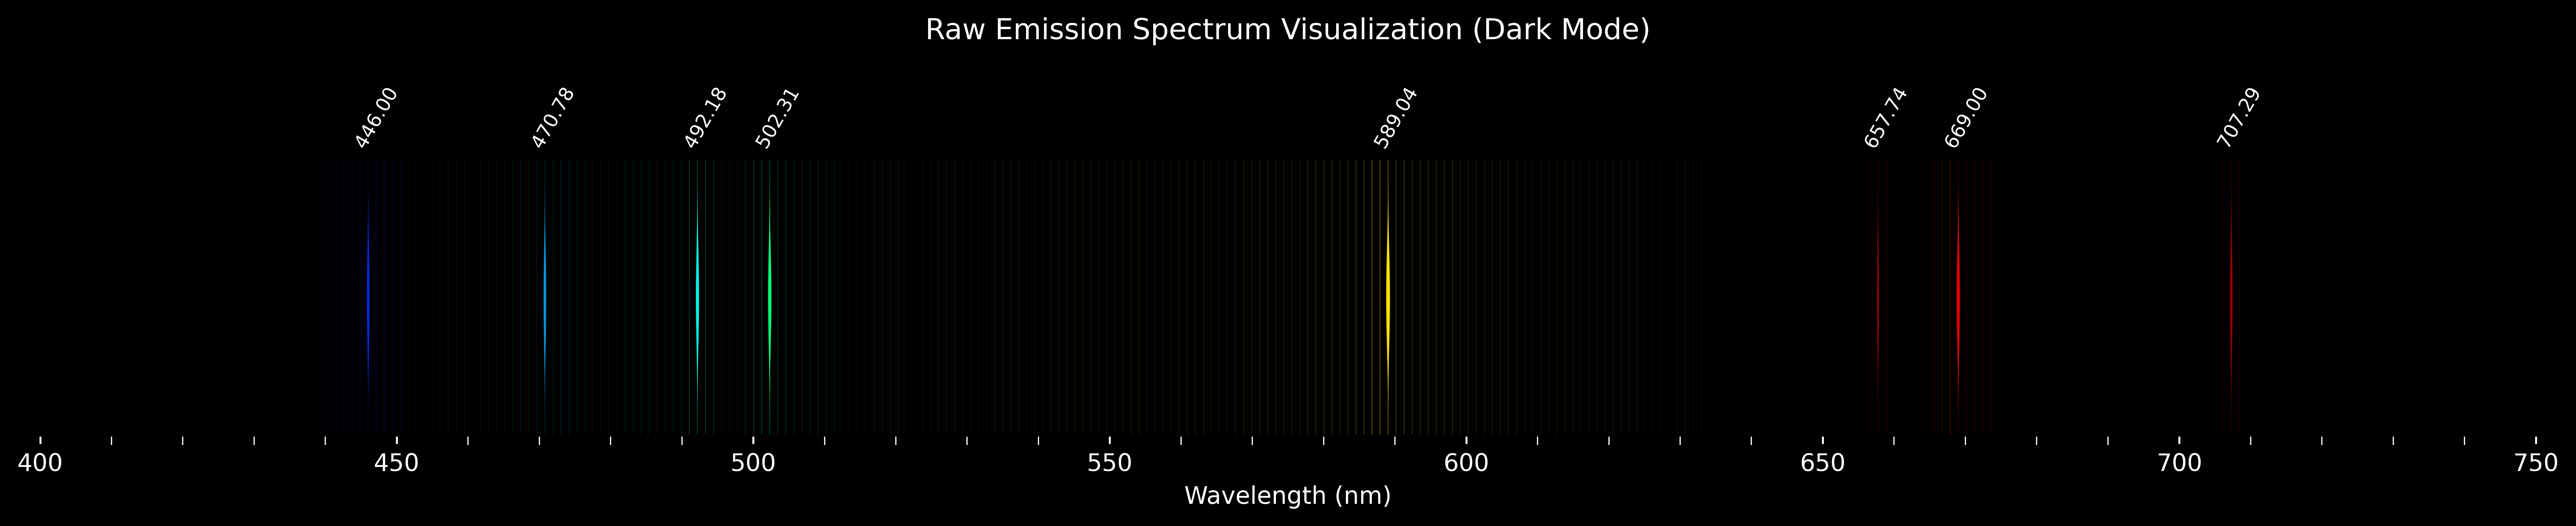

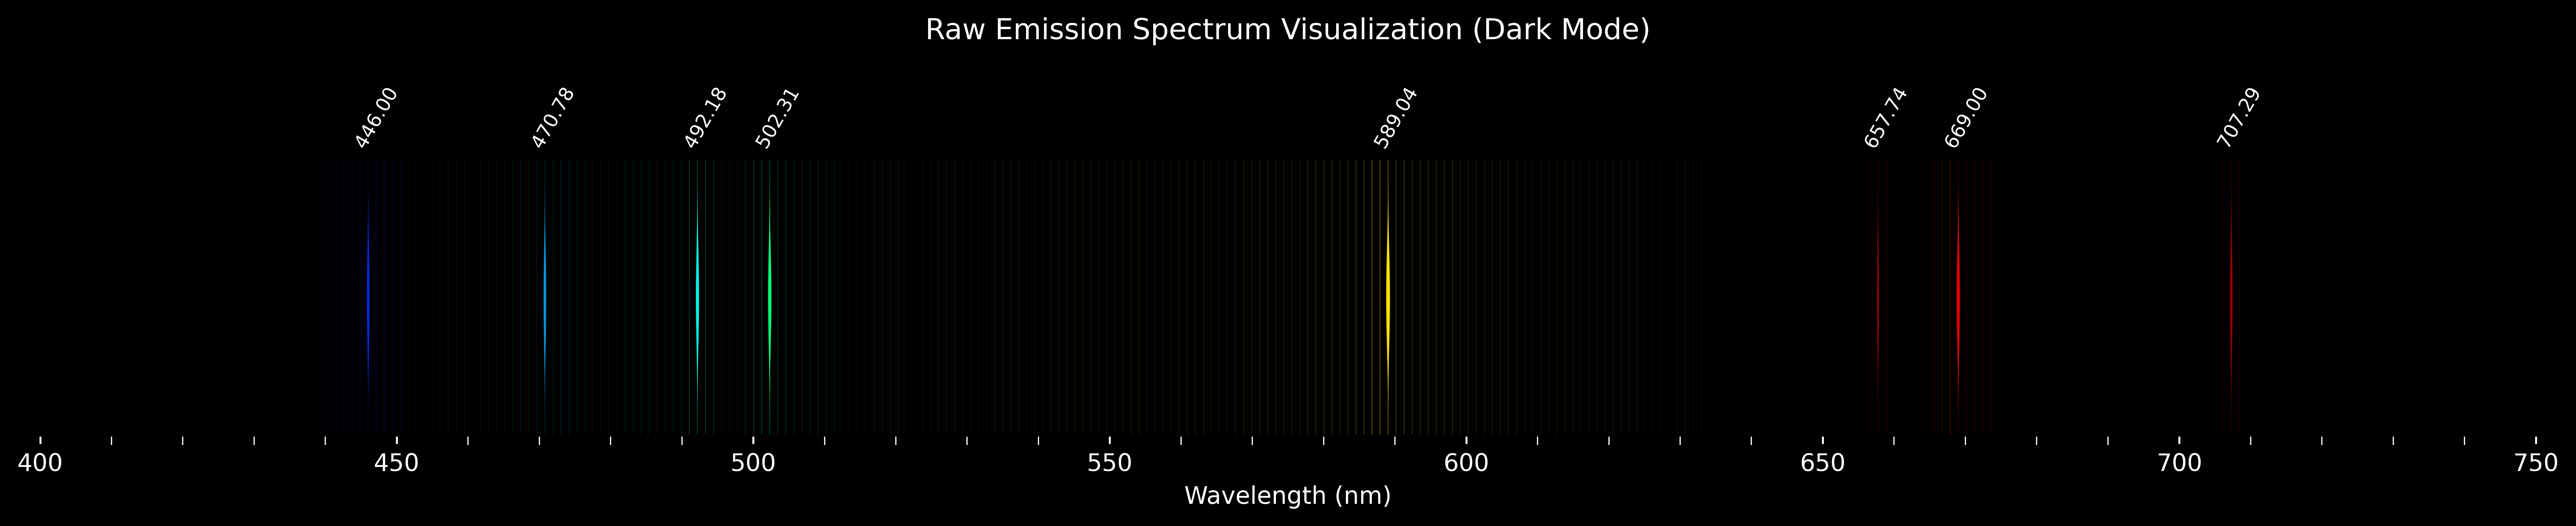

In [ ]:
trad_spec(df)

mode: dark
text colour: white face/bg colour: black
text colour: white bg colour: black mode: dark


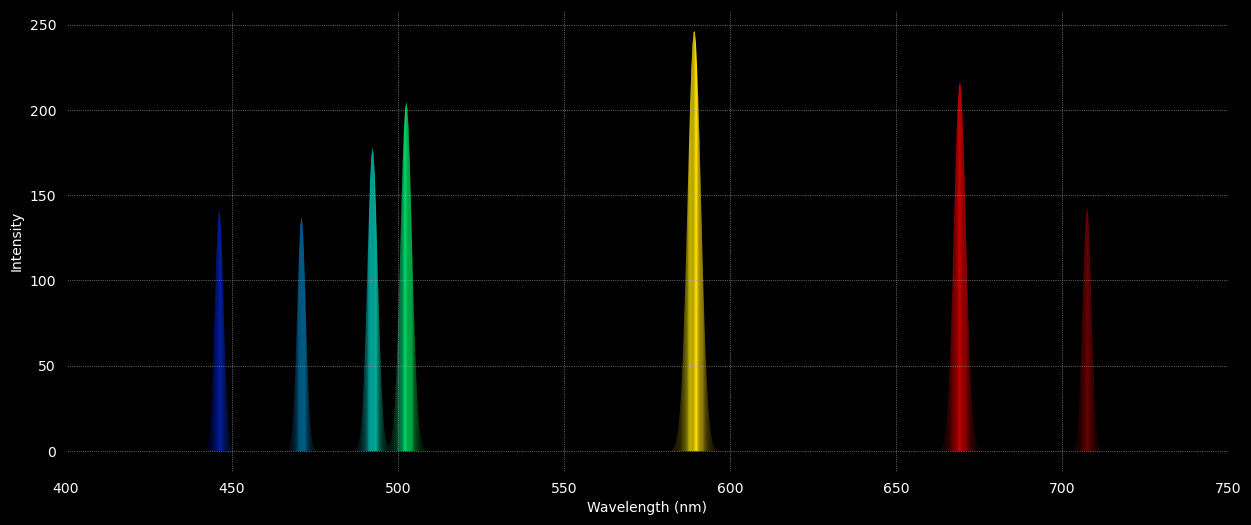

In [ ]:
new_utils.axis_labels()
gaussian_iteration()